# Introduction to Neural Networks - MicroTorch

# Installations

In [ ]:
%pip install numpy
%pip install pandas
%pip install matplotlib

# Imports

In [ ]:

import numpy as np
import pandas as pd
import io
import matplotlib.pyplot as plt
from helpers import plot_loss

# Neural Networks in MicroTorch




MicroTorch takes a slightly different approach. Instead of tracking operations in `Tensor` objects, each **module** (or layer) in MicroTorch will track its own inputs, outputs, and gradients. This simplified approach allows us to implement chaining through the modules themselves, making it easier to see how data flows through the network and how gradients are propagated backward.

## Abstract Base Classes

### Module Base Class

In [ ]:
class Module:
    def __init__(self):
        self.parameters = None  # Module parameters stored here
        self._delta = None  # Gradients saved from chaining backward()
        self._out = None  # Outputs of forward() saved for chaining
        self._in = None  # Inputs to forward() saved for chaining

    # Call to run the module during the forward pass
    # x is the numpy array containing (batched) inputs
    def forward(self, x):
        pass

    # Call to run the module during the backward pass
    # Delta is the gradient from the previous module's backward call.
    def backward(self, delta=1.0):
        pass

    # Call to update parameters
    # lr is the learning rate
    def update(self, lr):
        if self.parameters is not None:
            # print("dot: ", np.dot(self._in.T, self._delta))
            # print("param", self.parameters)
            self.parameters = self.parameters - (lr * np.dot(self._in.T, self._delta))

    # This makes it so that the object reference be called like a function.
    # When doing so, the forward function is automatically called.
    def __call__(self, x):
        return self.forward(x)

### Criterion Base Class

In [ ]:
class Criterion(Module):
    def __init__(self):
        super(Criterion, self).__init__()
        self._target = None  # Remember the target when forward is called

    # The forward function now takes two inputs:
    # y_hat is the prediction to be compared against the target
    # y is the target
    def forward(self, y_hat, y):
        pass

    # This makes it so that the object reference be called like a function.
    # When doing so, the forward function is automatically called.
    def __call__(self, x, y):
        return self.forward(x, y)

### Wrapper Functions for Forward and Backward Passes



In PyTorch, each `Tensor` object keeps track of operations applied to it, so chaining and gradient tracking happen automatically. However, in MicroTorch, we’re using regular numpy arrays, so we need to store this information manually. Wrappers ensure that every `forward` and `backward` function automatically saves the required values in each module.


```python
class MicroTorchLayer(Module):
  @layer_forward_wrapper
  def forward(self, x):
    return some_operation_on_x

  @layer_backward_wrapper
  def backward(self, delta):
    return delta * gradient_of_forward
```



In [ ]:

def layer_forward_wrapper(fn):
    def wrapper(*args, **kwargs):
        # The module is the first argument
        module = args[0]
        # The input is the second argument. Store it in the module
        module._in = args[1]
        result = fn(*args, **kwargs)
        # Store the result of the forward function in the module
        module._out = result
        return result

    return wrapper


# Put this decorator on any backward function for layer modules
def layer_backward_wrapper(fn):
    def wrapper(*args, **kwargs):
        # The module is the first argument
        module = args[0]
        # The delta is the second argument. Store it in the module
        module._delta = args[1]
        result = fn(*args, **kwargs)
        return result

    return wrapper


# Put this decorator on any forward function for layer modules
def criterion_forward_wrapper(fn):
    def wrapper(*args, **kwargs):
        # The module is the first argument
        module = args[0]
        # The input (y_hat) is the second argument. Store it in the module
        module._in = args[1]
        # The target (y) is the third argument. Store it in the module
        module._target = args[2]
        result = fn(*args, **kwargs)
        # Store the result of the backward function in the module
        module._out = result
        return result

    return wrapper


# Put this decorator on any backward function for criterion modules
def criterion_backward_wrapper(fn):
    def wrapper(*args, **kwargs):
        # The module is the first argument
        module = args[0]
        # The delta is the second argument. Store it in the module
        module._delta = args[1]
        result = fn(*args, **kwargs)
        return result

    return wrapper

## Criterion Modules

### MSE Class

In [ ]:

class MSE(Criterion):
    def __init__(self):
        super(MSE, self).__init__()

    @criterion_forward_wrapper
    def forward(self, x, y):

        difference = x-y
        return np.mean((difference)**2)



    @criterion_backward_wrapper
    def backward(self, delta=1.0):

        grad_input = 2 * (self._in - self._target) / self._in.shape[0]
        return delta * grad_input




### CrossEntropy Class

In [ ]:

class CrossEntropy(Criterion):
  def __init__(self):
    super(CrossEntropy, self).__init__()

  @criterion_forward_wrapper
  def forward(self, x, y):

    fullLoss = 0
    eps = 1e-10
    yshape = y.shape[0]
    for i in range(yshape):
      fullLoss += -np.log(x[i][y[i]] + eps)

    return (fullLoss / y.shape[0]).item()

  @criterion_backward_wrapper
  def backward(self, delta = 1.0):

    y = self._target
    numClasses = self._in.shape[1]
    oneHot = np.zeros((y.shape[0], numClasses))
    yshape = y.shape[0]
    for i in range(yshape):
      oneHot[i][y[i]] = 1
    return delta * (self._in - oneHot) / numClasses


## Layer Modules

### Sigmoid Class

In [ ]:

class Sigmoid(Module):
    def __init__(self):
        super(Sigmoid, self).__init__()

    @layer_forward_wrapper
    def forward(self, x):

        sigmoidF = 1 / (1 + np.exp(-x))
        return sigmoidF


    @layer_backward_wrapper
    def backward(self, delta=1.0):

        grad = self._out * (1 - self._out)
        return delta * grad


### ReLU Class

In [ ]:

class ReLU(Module):
    def __init__(self):
        super(ReLU, self).__init__()

    @layer_forward_wrapper
    def forward(self, x):

        reluF = np.maximum(0, x)
        return reluF

    @layer_backward_wrapper
    def backward(self, delta=1.0):

        grad = (self._in > 0).astype(float)
        return delta * grad



### Linear Class

In [ ]:

class Linear(Module):
    def __init__(self, input_size, output_size, bias=0.0):
        super(Linear, self).__init__()

        self.parameters = np.random.randn(input_size, output_size)
        self.bias = bias


    @layer_forward_wrapper
    def forward(self, x):

        return self.bias + np.dot(x, self.parameters)


    @layer_backward_wrapper
    def backward(self, delta=1.0):

        # print(delta)
        return np.dot(delta, np.transpose(self.parameters))


### Softmax Class

In [ ]:

class Softmax(Module):
    def __init__(self):
        super(Softmax, self).__init__()

    @layer_forward_wrapper
    def forward(self, x):

        sx = x - np.max(x, axis=1, keepdims=True)
        exp_x = np.exp(sx)
        softmaxF = exp_x / np.sum(exp_x, axis=1, keepdims=True)
        return softmaxF



    @layer_backward_wrapper
    def backward(self, delta=1.0):
        return delta

## Neural Network Class

In [ ]:

class NeuralNetwork:
    def __init__(self, lr=0.01, layers=[], criterion=None):

        self.layers = layers
        self.criterion = criterion
        self.lr = lr



    def forward(self, x):

        for layer in self.layers:
            x = layer(x)
        return x



    def compute_loss(self, x, y):

        return self.criterion(x,y)

    def backward(self):

        delta = self.criterion.backward(1.0)
        for layer in reversed(self.layers):
            delta = layer.backward(delta)
        return delta


    # Update the parameters of the neural network
    def update(self):

        for layer in self.layers:
            layer.update(self.lr)


    # You can call a NeuralNetwork object like a function. This calls the forward function.
    def __call__(self, x):
        return self.forward(x)

    # Add a layer object
    def add_layer(self, layer):
        self.layers.append(layer)

    # Provide a list of layer objects
    def set_layers(self, layers):
        self.layers = layers

    # Provide the criterion object
    def set_criterion(self, criterion):
        self.criterion = criterion

    # Provide the learning rate
    def set_lr(self, lr):
        self.lr = lr

    # Clear the gradients of all the layers
    def zero_grad(self):
        for layer in self.layers:
            layer._delta = None

## XOR Problem

In [ ]:
input_csv = """
observation,input1,input2,output
1,0,0,0
2,0,1,1
3,1,0,1
4,1,1,0
"""
xor_dataset = pd.read_csv(io.StringIO(input_csv), index_col="observation")
xor_inputs = xor_dataset.iloc[:,:-1].to_numpy().astype('float32')
xor_targets = xor_dataset.iloc[:,-1].to_numpy().reshape(-1, 1).astype('float32')

## Building a Neural Network using MicroTorch to Solve XOR

In [ ]:

# Initialize the layers, criterion, and model with classification objective
def setup_classification_model():
    """
    Write your layers as a list of Layer modules (you have flexibility as to the architecture,
    though we recommend using a couple linear layers). Set the criterion as CrossEntropy
    """

    ce_model = None

    layers = [
        Linear(2,4),
        ReLU(),
        Linear(4,2),
        Softmax()
    ]
    ce_model = NeuralNetwork(layers=layers, criterion=CrossEntropy())

    return ce_model

In [ ]:
ce_model = setup_classification_model()

In [ ]:

# Initialize the layers, criterion, and model with regression objective
def setup_regression_model():
    """
    Write your layers as a list of Layer modules (you have flexibility as to the architecture,
    though we recommend using a couple linear layers). Set the criterion as MSE.
    """

    mse_model = None

    layers = [
        Linear(2,8),
        Sigmoid(),
        Linear(8,1),
        Sigmoid()
    ]
    mse_model = NeuralNetwork(layers=layers, criterion=MSE())

    return mse_model

In [ ]:
mse_model = setup_regression_model()

### Training Loop

In [ ]:

def train_model(model, x, y, mode='classification', lr=0.1, num_iterations=50000, plot_losses=True):
    """
    Train a neural network on the XOR problem with a specified mode (classification or regression).

    Parameters:
    - model (NeuralNetwork): The neural network model to train.
    - mode (str): The mode of the task, either 'classification' or 'regression'.
    - lr (float): Learning rate.
    - num_iterations (int): Number of training iterations.
    - plot_losses (bool): Whether to plot the losses.
    """
    y = y.astype('int32') if mode == 'classification' else y
    # Training loop
    loss_values = []
    model.zero_grad()  # Reset gradients
    model.set_lr(lr)  # Set learning rate

    for i in range(num_iterations):
        """
        Write code to do the forward, loss, backwards, and update routine
        Please store your loss in a variable called `loss`
        """
        loss = None

        loss = model(x)
        loss = model.compute_loss(loss, y)
        model.backward()
        model.update()


        # Store and print loss
        loss_values.append(loss)
        if plot_losses == True and i % 2000 == 0:
            print(f"Iteration {i:5d} | Loss: {loss:.6f}")
            plot_loss(loss_values, dynamic=True)

    # Final plot
    if plot_losses == True:
        plot_loss(loss_values, dynamic=False)
        plt.show()
    return loss_values

### Train XOR as a Classification Task


In [ ]:

# Set classification Hyperparameters for training here - we've given default values - these may not be optimal,
# so you will want to experiment with different values
def set_classification_parameters():

    LR = 0.5
    NUM_ITERATIONS = 3000

    return LR, NUM_ITERATIONS

In [ ]:
# Prepare data
x = xor_inputs
y = xor_targets


<Figure size 640x480 with 0 Axes>

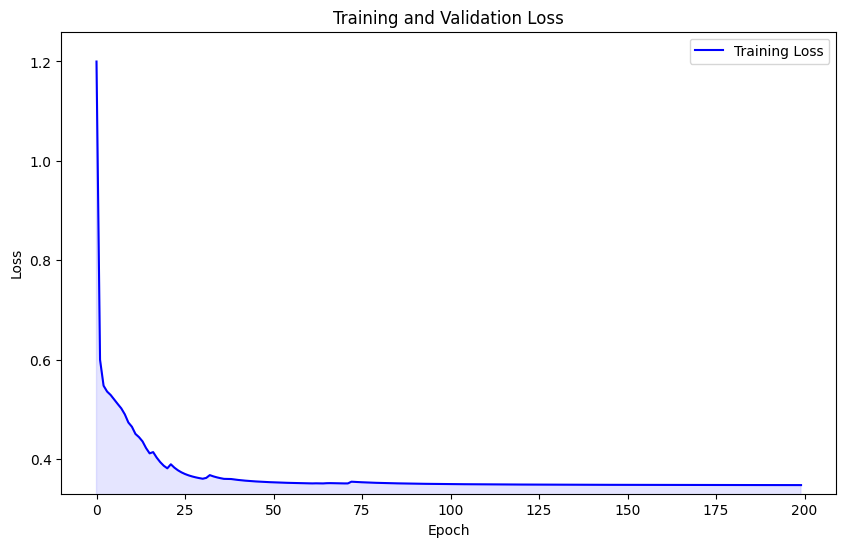

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [ ]:
LR, NUM_ITERATIONS = set_classification_parameters()

# For classification
_ = train_model(ce_model, x, y, mode='classification', lr=LR, num_iterations=NUM_ITERATIONS)

In [ ]:
# Calculate the Classification Accuracy
y_hat = ce_model(xor_inputs.astype('int'))
y_pred = np.argmax(y_hat, axis=1)
accuracy = np.mean(y_pred == xor_targets.squeeze())

print("\nModel Predictions:")
print(y_pred.reshape(-1, 1))

print("\nTarget Values:")
print(xor_targets.astype('int'))

print(f"\nClassification Accuracy: {accuracy:.2f}")


Model Predictions:
[[0]
 [1]
 [1]
 [0]]

Target Values:
[[0]
 [1]
 [1]
 [0]]

Classification Accuracy: 1.00


### Train XOR as Regression Task

In [ ]:

# Set regression hyperparameters for training here - we've given default values - these may not be optimal,
# so you will want to experiment with different values
def set_regression_parameters():

    LR = 0.5
    NUM_ITERATIONS = 3000

    return LR, NUM_ITERATIONS

<Figure size 640x480 with 0 Axes>

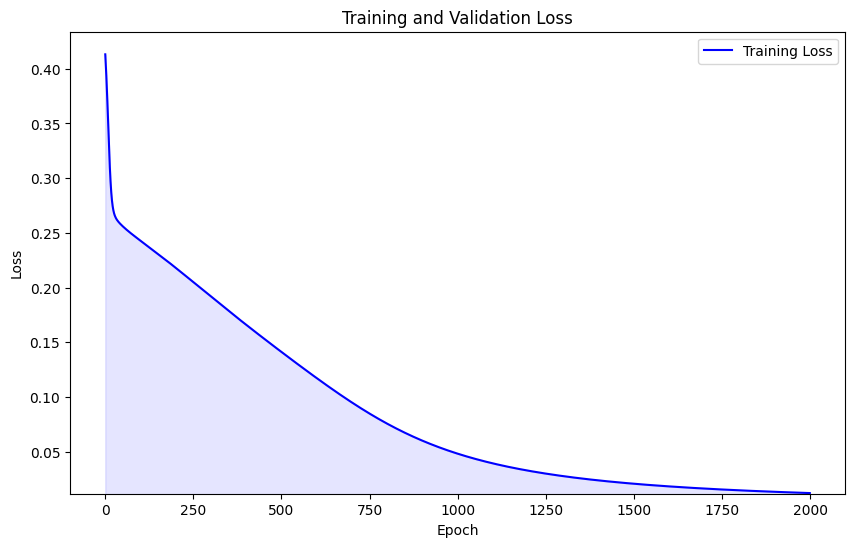

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [ ]:
LR, NUM_ITERATIONS = set_regression_parameters()

# For regression
_ = train_model(mse_model, x, y, mode='regression', lr=LR, num_iterations=NUM_ITERATIONS)

In [ ]:
y_hat = mse_model(xor_inputs)
y = xor_targets

print("Model Outputs:")
print(np.round(y_hat, decimals=3))

print("\nTarget Values:")
print(y)

mean_difference = np.mean(np.abs(y - y_hat))
print(f"\nMean Absolute Difference (Error): {mean_difference:.6f}")

Model Outputs:
[[0.123]
 [0.891]
 [0.891]
 [0.096]]

Target Values:
[[0.]
 [1.]
 [1.]
 [0.]]

Mean Absolute Difference (Error): 0.109584
